# 테슬라 주가 예측 프로그램 (SimpleRNN 기반)

이 노트북은 테슬라 주가 데이터(`TSLA.csv`)를 활용하여 과제의 요구사항에 맞춰 SimpleRNN 모델을 학습시키고 주가를 예측하는 프로그램입니다.

In [41]:
# 필요한 핵심 라이브러리 및 텐서플로우 컴포넌트들을 불러옵니다.
from google.colab import drive           # 구글 드라이브 파일 시스템 연결용 모듈
import pandas as pd                    # 데이터프레임 가공 및 파일 입력용 Pandas
import numpy as np                     # 고성능 행렬 및 수치 연산 라이브러리
import matplotlib.pyplot as plt         # 2D 데이터 시각화 및 그래프 드로잉 라이브러리
from sklearn.preprocessing import MinMaxScaler  # 데이터를 일정 범위(0~1)로 압축하는 정규화 모듈
from tensorflow.keras.models import Sequential  # 순차 구조의 인공지능 레이어를 쌓는 모델 프레임
from tensorflow.keras.layers import SimpleRNN, Dense, Input  # SimpleRNN 레이어 및 Dense, Input 클래스 불러오기

In [42]:
# 1. 구글 드라이브를 가상 경로에 마운트하고 테슬라 주가 CSV 파일을 로드합니다.
drive.mount('/content/drive')  # 구글 계정 인증을 통해 클라우드 드라이브 연동

# TSLA.csv 파일을 읽어 들여 Pandas 데이터프레임 객체로 로딩합니다.
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA/TSLA.csv')

# 학습 모델이 주가 트렌드를 읽어내고 예측할 수 있도록 타겟 열인 종가('Close') 데이터를 2차원 배열 형태로 추출합니다.
data = df['Close'].values.reshape(-1,1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# 2. 모델의 안정적인 오차 수렴과 효율적인 경사하강법 진행을 위해 데이터를 0과 1 사이로 강제 정규화(스케일링)합니다.
scaler = MinMaxScaler(feature_range=(0, 1))  # 0~1 범위를 지정하는 객체 선언
scaled_data = scaler.fit_transform(data)     # 전체 종가 원본 데이터를 스케일러 범위에 맞춤 피팅 및 변형

# 시계열 정보의 특성을 파괴하지 않기 위해 무작위 셔플링을 피하고 순차적으로 데이터의 80%는 훈련에, 20%는 평가 테스트용으로 나눕니다.
train_size = int(len(scaled_data) * 0.8)     # 80%에 해당하는 데이터 개수(인덱스 위치) 계산
train_data = scaled_data[:train_size]         # 앞부분 80%에 해당하는 훈련 데이터 블록 생성
test_data = scaled_data[train_size:]          # 뒷부분 20%에 해당하는 검증 테스트 데이터 블록 생성

In [44]:
# 3. 주가 변동 패턴 학습을 위해 데이터를 정해진 윈도우 크기(타임스텝) 단위의 학습용 샘플(X, Y) 세트로 가공합니다.
def make_sample(dataset, window):
    train, target = [], []  # 입력 데이터(X)와 실측 정답(Y)을 차곡차곡 모으기 위한 임시 보관 리스트
    for i in range(len(dataset) - window):  # 전체 크기에서 윈도우 간격을 뺀 잔여 구간만큼 루프 가동
        train.append(dataset[i:(i + window)])  # 0번부터 시작해 window 길이만큼의 과거 데이터를 입력 인풋(X)으로 수집
        target.append(dataset[i + window])     # 입력 기간의 바로 다음 날(내일) 주가를 타겟 정답(Y)으로 설정
    return np.array(train), np.array(target)   # 수집 완료된 파이썬 리스트들을 딥러닝 텐서 형식에 맞는 넘파이 배열로 변환

# 과제 기준에 맞추어 7일의 영업일 기간(7일)을 타임스텝의 창(Window) 크기로 잡습니다.
window = 7
X_train, Y_train = make_sample(train_data, window)  # 정규화된 훈련 데이터를 패턴 학습용 쌍으로 가공
X_test, Y_test = make_sample(test_data, window)      # 정규화된 테스트 데이터를 성능 확인용 쌍으로 가공

In [45]:
# 4. 과제 명세에 명시된 SimpleRNN 신경망 모델 구조를 빌드합니다.
model = Sequential([
    Input(shape=(window, 1)),  # 입력 노드: (시간 윈도우=7, 특성 차원=1 [종가 단일값])
    # 64개의 메모리 셀을 장착한 순수 SimpleRNN 레이어 적용. 
    # return_sequences=False로 지정해 마지막 스텝의 은닉 상태 벡터만 다음 밀집층으로 보냅니다.
    SimpleRNN(64, activation='tanh', return_sequences=False),
    # 특성 강화를 위한 완전연결 은닉층(Dense)과 ReLU 활성화 오차 필터 적용
    Dense(32, activation='relu'),
    # 최종 예측 주가를 출력하는 완전연결층. 회귀 문제를 풀기 위해 인풋된 신호를 억제하는 활성화 함수는 배제합니다.
    Dense(1)  
])

# 평균제곱오차(MSE) 손실함수와 역전파 가속기인 Adam 옵티마이저를 사용해 결합을 컴파일합니다.
model.compile(optimizer='adam', loss='mse')

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.0993e-05 - val_loss: 0.0079
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6379e-06 - val_loss: 0.0065
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2762e-06 - val_loss: 0.0064
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2051e-06 - val_loss: 0.0071
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6826e-06 - val_loss: 0.0073
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4976e-06 - val_loss: 0.0077
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3584e-06 - val_loss: 0.0065
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2889e-06 - val_loss: 0.0058
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9774e-06 - val_loss: 0.0048
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0952e-06 - val_loss: 0.0043
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5836e-06 - val_loss: 0.0056
Epoch 12/100
74/74 

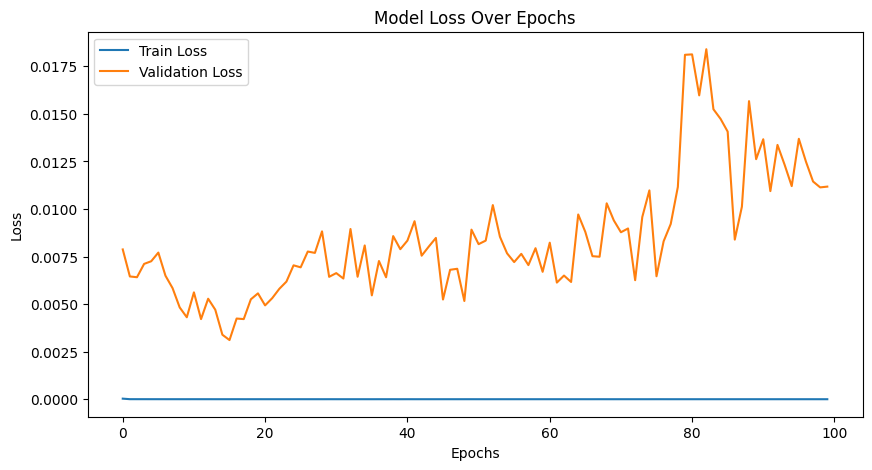

In [46]:
# 5. 모델 학습 루프를 100회(Epochs) 반복 구동합니다.
history = model.fit(
    X_train, Y_train,
    epochs=100,           # 전체 데이터 세트에 대해 100번 반복 학습 수행
    batch_size=32,         # 메모리 효율을 고려해 한 번에 32개씩 묶어 업데이트
    validation_data=(X_test, Y_test),  # 학습 중간 모니터링을 위해 검증용 테스트 세트 동시 제공
    verbose=1             # 터미널 화면에 매 세대마다의 손실률 지표(Loss) 출력
)

# 학습 추이에 따른 모델의 손실(MSE) 하락 폭을 선형 그래프로 나타냅니다.
plt.figure(figsize=(10, 5))                              # 캔버스 너비와 높이 배율 정의
plt.plot(history.history['loss'], label='Train Loss')            # 훈련 학습 시의 오차 기록 변화선
plt.plot(history.history['val_loss'], label='Validation Loss')    # 검증 시뮬레이션 오차 기록 변화선
plt.title('Model Loss Over Epochs')                              # 차트 헤더 타이틀
plt.xlabel('Epochs')                                             # X축 라벨: 에포크 학습 수
plt.ylabel('Loss')                                               # Y축 라벨: 손실 수치
plt.legend()                                                     # 식별 라벨 범례 띄우기
plt.show()                                                       # 시각화 실행

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


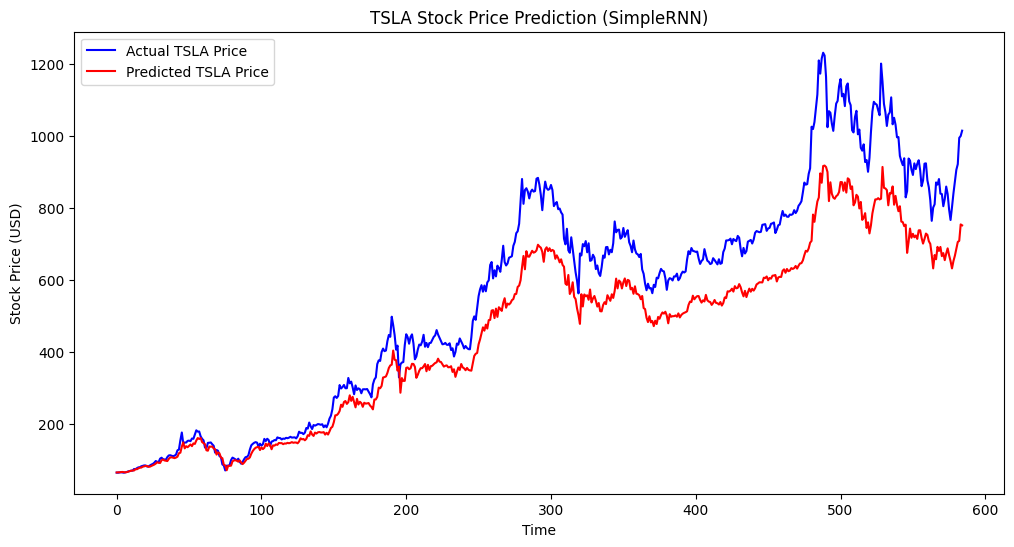

In [47]:
# 6. 학습 완성된 SimpleRNN 모델을 통해 미래 주가 예측에 나섭니다.
predictions = model.predict(X_test)  # 테스트 데이터를 투입해 모델 추론값 추출

# 정규화되어 복잡해진 추론 데이터([0~1])를 MinMaxScaler 역연산을 거쳐 실제 가격대(USD) 단위로 복원합니다.
predictions_inverse = scaler.inverse_transform(predictions)
# 정답 비교군인 Y_test 실제 종가 정답 역시 달러 단위로 복원해 줍니다.
actual_prices = scaler.inverse_transform(Y_test.reshape(-1, 1))

# 실제 주가와 SimpleRNN이 예측해낸 주가 궤적을 겹쳐 가시화합니다.
plt.figure(figsize=(12, 6))  # 최적의 2D 그래프 공간 구성
plt.plot(actual_prices, label='Actual TSLA Price', color='blue')        # 실제 주가 곡선
plt.plot(predictions_inverse, label='Predicted TSLA Price', color='red')  # SimpleRNN 예측 주가 곡선
plt.title('TSLA Stock Price Prediction (SimpleRNN)')                     # 그래프 메인 제목
plt.xlabel('Time')                                                       # X축 정보: 상대 경과일
plt.ylabel('Stock Price (USD)')                                          # Y축 정보: 환산 가격(달러)
plt.legend()                                                             # 라벨 안내선 구성
plt.show()                                                               # 그래프 화면 출력